In [1]:
from gctm_jcgs_simulation_study_helpers import *
import os
import pickle

/Users/matthiasherp/anaconda3/envs/mctm_pytorch/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# go up one in working directory to be in the same directory as the mlflow runs
os.chdir("..")

In [3]:
# create a plot where we input rvine_kld_dict_weighted_no_pen, rvine_kld_dict_lambda_pen and rvine_kld_dict_weighted_lambda_pen
# we then plot on the x axis the sample size e.g.g 125, 250, 500, 1000, 2000, 4000
# on the y axis we put the rel_kld_test
# for each we want the mean over seeds as a point and the upper 80 and lower 20 percentage quantile as wiskers

import numpy as np
import matplotlib.pyplot as plt

# Function to compute mean, 20th, and 80th percentiles
def compute_stats(data_dict, experiment_strings, metric = "rel_kld_test"):
    means = []
    lower_quantiles = []
    upper_quantiles = []
    for size in experiment_strings:
        if metric is not False:
            values = data_dict[size][metric]
        else:
            values = data_dict[size]
        # drop extereme values above 5
        #values = [x for x in values if x < 3]
        means.append(np.mean(values))
        lower_quantiles.append(np.percentile(values, 5))
        upper_quantiles.append(np.percentile(values, 95))
    return means, lower_quantiles, upper_quantiles

def create_comparison_plot_one_scenario(
    kld_dict_no_lambda_pen,
    kld_dict_lambda_pen,
    kld_dict_weighted_lambda_pen,
    metric = "rel_kld_test",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000, 2000, 4000],
    experiment_strings = ["rvine_10_dim_125obs", "rvine_10_dim_250obs", "rvine_10_dim_1000obs", "rvine_10_dim_2000obs", "rvine_10_dim"],
    y_min = False,
    y_max = False,
    benchmark=False,
    legend=False,
    metric_str="AUC"
):
    # Define sample sizes
    #experiment_strings = list(kld_dict_no_lambda_pen.keys())

    # Compute statistics for each method
    means_weighted_no_pen, lower_weighted_no_pen, upper_weighted_no_pen = compute_stats(kld_dict_no_lambda_pen, experiment_strings, metric)
    means_lambda_pen, lower_lambda_pen, upper_lambda_pen = compute_stats(kld_dict_lambda_pen, experiment_strings, metric)
    means_weighted_lambda_pen, lower_weighted_lambda_pen, upper_weighted_lambda_pen = compute_stats(kld_dict_weighted_lambda_pen, experiment_strings, metric)
    if benchmark is not False:
        means_benchmark, lower_benchmark, upper_benchmark = compute_stats(benchmark, experiment_strings, metric=False)

    # Define evenly spaced x positions for the sample sizes
    x_positions = np.arange(len(sample_sizes))

    # Updated plotting with side-by-side whisker plots
    offset = 0.2  # Offset for separating whisker plots within each sample size group

    plt.figure(figsize=(5, 4))

    # Adjusted x positions for each method
    if benchmark is not False:
        x_benchmark = x_positions - offset
        x_weighted_no_pen = x_positions - 0.33 * offset
        x_lambda_pen = x_positions + 0.33 * offset
        x_weighted_lambda_pen = x_positions + offset
        
        plt.errorbar(x_benchmark, means_benchmark, 
                yerr=[np.array(means_benchmark) - np.array(lower_benchmark),
                    np.array(upper_benchmark) - np.array(means_benchmark)],
                label="GGM", 
                fmt='o', linestyle='', capsize=5, color="#d62728") #red
    else:
        x_weighted_no_pen = x_positions - offset
        x_lambda_pen = x_positions
        x_weighted_lambda_pen = x_positions + offset

    # Plot each method with error bars
    plt.errorbar(x_weighted_no_pen, means_weighted_no_pen, 
                yerr=[np.array(means_weighted_no_pen) - np.array(lower_weighted_no_pen),
                    np.array(upper_weighted_no_pen) - np.array(means_weighted_no_pen)],
                label="No LASSO Penalty", 
                fmt='o', linestyle='', capsize=5, color="#1f77b4") #blue

    plt.errorbar(x_lambda_pen, means_lambda_pen, 
                yerr=[np.array(means_lambda_pen) - np.array(lower_lambda_pen),
                    np.array(upper_lambda_pen) - np.array(means_lambda_pen)],
                label="LASSO Penalty", 
                fmt='o', linestyle='', capsize=5, color="#ff7f0e") #orange

    plt.errorbar(x_weighted_lambda_pen, means_weighted_lambda_pen, 
                yerr=[np.array(means_weighted_lambda_pen) - np.array(lower_weighted_lambda_pen),
                    np.array(upper_weighted_lambda_pen) - np.array(means_weighted_lambda_pen)],
                label="Adaptive LASSO Penalty", 
                fmt='o', linestyle='', capsize=5, color="#2ca02c") #green

    # Formatting
    plt.xticks(x_positions, sample_sizes)  # Replace numeric x positions with sample size labels
    plt.xlabel("Sample Size")
    plt.ylabel(metric_str)
    #plt.title(title_str + ": " + metric)
    if legend == True:
        plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    # min 0.5 max 1 on the y axis
    if y_min is not False and y_max is not False:
        plt.ylim(y_min, y_max)
    #plt.show()

In [4]:
experiment = mlflow.get_experiment_by_name("rine_10D_250obs_bootstrap_hydra_fixed_copula_minimal5") 
df_runs = mlflow.search_runs([experiment.experiment_id])
subset = df_runs

In [5]:
def get_rel_kld_experiment(experiment_name="rvine_10_dim", 
                                      name_ending_look_for=False, 
                                      name_endings_not_look_for_list=False,
                                      seed_min=False, 
                                      seed_max=False,
                                      kld_available=False,
                                      print_info=False,
                                      print_run_names=False,
                                      copula=False):
    
    experiment = mlflow.get_experiment_by_name(experiment_name) 
    df_runs = mlflow.search_runs([experiment.experiment_id])
    subset = df_runs
    
    if name_ending_look_for is not False:
        subset = subset[[name_ending_look_for in subset.iloc[i]["tags.mlflow.runName"] for i in range(subset.shape[0])]]
        
    if name_endings_not_look_for_list is not False:
        for name_ending_not_look_for in name_endings_not_look_for_list:
            subset = subset[[name_ending_not_look_for not in subset.iloc[i]["tags.mlflow.runName"] for i in range(subset.shape[0])]]
    
    if seed_min is not False:
        subset = subset[[int(subset.iloc[i]["tags.seed_value"]) >= seed_min for i in range(subset.shape[0])]]
    if seed_max is not False:
        subset = subset[[int(subset.iloc[i]["tags.seed_value"]) <= seed_max for i in range(subset.shape[0])]]
    

    subset_pen = subset#[0:15] # if the most recent seed is still running
    if print_run_names is True: 
        print(subset_pen["tags.mlflow.runName"].to_numpy())
        print(subset_pen["tags.mlflow.runName"].to_numpy().shape)
    
    
    dict_rel_kld = {}

    list_rel_kld_test = []
    list_rel_kld_train = []
    for i in range(len(subset)):
        subset_pen = subset.iloc[i]
        test_rel_kld_pen = subset_pen["metrics.relative_kld_gtm_test"]
        train_rel_kld_pen = subset_pen["metrics.relative_kld_gtm_train"]
        
        list_rel_kld_test.append(test_rel_kld_pen) 
        list_rel_kld_train.append(train_rel_kld_pen)
        
    dict_rel_kld["rel_kld_test"] = list_rel_kld_test
    dict_rel_kld["rel_kld_train"] = list_rel_kld_train
    
    return dict_rel_kld


In [6]:
experiment_name_list = [
                        "rine_10D_250obs_bootstrap_hydra_fixed_copula_minimal5",  
                        "rine_10D_500obs_bootstrap_hydra_fixed_copula_minimal5",  
                        "rine_10D_1000obs_bootstrap_hydra_fixed_copula_minimal5", 
                        "rine_10D_2000obs_bootstrap_hydra_fixed_copula_minimal5" ]
rvine_kld_dict_no_lambda_pen = {}
for experiment_name in experiment_name_list:

    dict = get_rel_kld_experiment(experiment_name=experiment_name, 
                                        name_ending_look_for=False, 
                                        name_endings_not_look_for_list=["bootstrap"],
                                        seed_min=1, 
                                        seed_max=80,
                                        kld_available=False,
                                        print_info=False,
                                        print_run_names=False,
                                        copula=False)
    
    rvine_kld_dict_no_lambda_pen[experiment_name] = dict

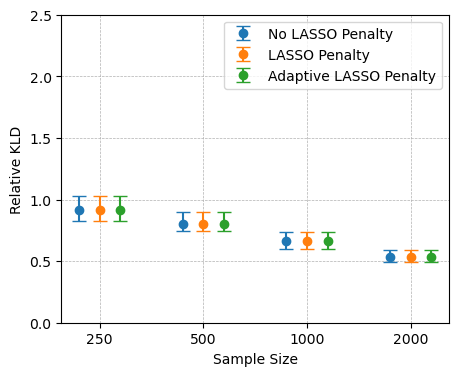

In [7]:
create_comparison_plot_one_scenario(
    rvine_kld_dict_no_lambda_pen,
    rvine_kld_dict_no_lambda_pen,
    rvine_kld_dict_no_lambda_pen,
    metric = "rel_kld_test",
    title_str = "R-Vine",
    sample_sizes = [250, 500, 1000, 2000],
    experiment_strings=experiment_name_list,
    y_min = 0.,
    y_max = 2.5,
    legend=True,
    metric_str="Relative KLD"
)
# save plot
#plt.savefig("gctm_jcgs_plots/rvine_kld_v2.png")

In [8]:
[col for col in df_runs.columns if 'auc' in col]

['metrics.auc_cond_corr_val',
 'metrics.auc_cond_corr',
 'metrics.auc_loglik_diff_val',
 'metrics.auc_cond_corr_data',
 'metrics.auc_loglik_diff_train',
 'metrics.auc_cond_corr_train',
 'metrics.auc_precision_matrix',
 'metrics.auc_loglik_diff_data',
 'metrics.auc_iae',
 'metrics.auc_precision_matrix_train',
 'metrics.auc_precision_matrix_val',
 'metrics.auc_precision_matrix_data',
 'metrics.auc_kld']

In [9]:
def get_auc_across_metrics_experiment(experiment_name=experiment_name, 
                                            name_ending_look_for=False, 
                                            name_endings_not_look_for_list=False,
                                            seed_min=1, 
                                            seed_max=30,
                                            print_run_names=False,):
    
    experiment = mlflow.get_experiment_by_name(experiment_name) 
    df_runs = mlflow.search_runs([experiment.experiment_id])
    subset = df_runs
    
    if name_ending_look_for is not False:
        subset = subset[[name_ending_look_for in subset.iloc[i]["tags.mlflow.runName"] for i in range(subset.shape[0])]]
        
    if name_endings_not_look_for_list is not False:
        for name_ending_not_look_for in name_endings_not_look_for_list:
            subset = subset[[name_ending_not_look_for not in subset.iloc[i]["tags.mlflow.runName"] for i in range(subset.shape[0])]]
    
    if seed_min is not False:
        subset = subset[[int(subset.iloc[i]["tags.seed_value"]) >= seed_min for i in range(subset.shape[0])]]
    if seed_max is not False:
        subset = subset[[int(subset.iloc[i]["tags.seed_value"]) <= seed_max for i in range(subset.shape[0])]]
    

    subset_pen = subset#[0:15] # if the most recent seed is still running
    if print_run_names is True: 
        print(subset_pen["tags.mlflow.runName"].to_numpy())
        print(subset_pen["tags.mlflow.runName"].to_numpy().shape)
    
    
    # First, get the list of all columns containing "auc"
    auc_columns = [col for col in subset.columns if 'auc' in col]

    dict_auc = {}

    # Initialize each auc column's list in the dictionary
    for auc_col in auc_columns:
        dict_auc[auc_col] = []

    # Loop over the rows and collect values for each auc column
    for i in range(len(subset)):
        row = subset.iloc[i]
        for auc_col in auc_columns:
            dict_auc[auc_col].append(float(row[auc_col]))
    
    return dict_auc


In [10]:
experiment_name_list = [
                        "rine_10D_250obs_bootstrap_hydra_fixed_copula_minimal5",  
                        "rine_10D_500obs_bootstrap_hydra_fixed_copula_minimal5",  
                        "rine_10D_1000obs_bootstrap_hydra_fixed_copula_minimal5", 
                        "rine_10D_2000obs_bootstrap_hydra_fixed_copula_minimal5" ]


rvine_auc_dict_no_lambda_pen = {}
for experiment_name in experiment_name_list:
    dict = get_auc_across_metrics_experiment(experiment_name=experiment_name, 
                                                name_ending_look_for=False, 
                                                name_endings_not_look_for_list=["bootstrap"],
                                                seed_min=1, 
                                                seed_max=80,
                                                print_run_names=False,)
            
    rvine_auc_dict_no_lambda_pen[experiment_name] = dict

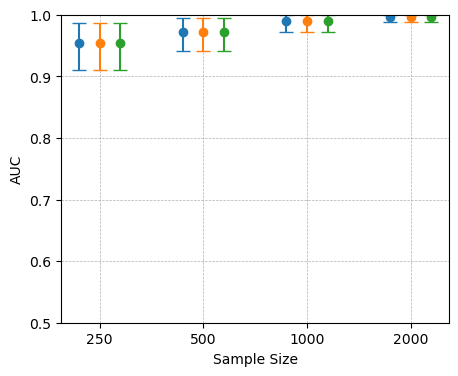

In [11]:
create_comparison_plot_one_scenario(
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_no_lambda_pen,
    metric = "metrics.auc_loglik_diff_data",
    title_str = "R-Vine",
    sample_sizes = [250, 500, 1000, 2000],
    experiment_strings=experiment_name_list,
    y_min = 0.5,
    y_max = 1,
    benchmark=False
)
# save plot
#plt.savefig("gctm_jcgs_plots/cvine_auc_pmatrix.png")

## Varying Copula

In [12]:
experiment_name_list = [
                        "rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5"#, 
                        #"rine_10D_2000obs_bootstrap_hydra_varying_copula_minimal5" 
                        ]
rvine_kld_dict_no_lambda_pen = {}
for experiment_name in experiment_name_list:

    dict = get_rel_kld_experiment(experiment_name=experiment_name, 
                                        name_ending_look_for=False, 
                                        name_endings_not_look_for_list=["bootstrap"],
                                        seed_min=0, 
                                        seed_max=99,
                                        kld_available=False,
                                        print_info=False,
                                        print_run_names=False,
                                        copula=False)
    
    rvine_kld_dict_no_lambda_pen[experiment_name] = dict

In [13]:
experiment_name_list = [ 
                        "rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5_lassopen",  
                        "rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5_lassopen",  
                        "rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5_lassopen",  
                        "rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5_lassopen" ]
rvine_kld_dict_lambda_pen = {}
for experiment_name in experiment_name_list:

    dict = get_rel_kld_experiment(experiment_name=experiment_name, 
                                        name_ending_look_for="meanedlassopen", 
                                        name_endings_not_look_for_list=["bootstrap"],
                                        seed_min=0, 
                                        seed_max=99,
                                        kld_available=False,
                                        print_info=False,
                                        print_run_names=False,
                                        copula=False)
    
    rvine_kld_dict_lambda_pen[experiment_name] = dict

In [14]:
experiment_name_list = [ 
                        "rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted",  
                        "rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted",  
                        "rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted",  
                        "rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted"]
rvine_kld_dict_lambda_pen_weighted = {}
for experiment_name in experiment_name_list:

    dict = get_rel_kld_experiment(experiment_name=experiment_name, 
                                        name_ending_look_for="meanedlassopen", 
                                        name_endings_not_look_for_list=["bootstrap"],
                                        seed_min=0, 
                                        seed_max=99,
                                        kld_available=False,
                                        print_info=False,
                                        print_run_names=False,
                                        copula=False)
    
    rvine_kld_dict_lambda_pen_weighted[experiment_name] = dict

In [15]:
import numpy as np

def remove_nans_dict(rvine_kld_dict):
    nan_counts = {}
    for key, val_list in rvine_kld_dict.items():
        # Convert to numpy array for convenience
        arr = np.array(val_list["rel_kld_test"], dtype=float)
        nan_mask = np.isnan(arr)
        num_nans = np.sum(nan_mask)
        nan_counts[key] = num_nans
        # Remove nans and update the dict
        rvine_kld_dict[key]["rel_kld_test"] = arr[~nan_mask].tolist()
    return rvine_kld_dict, nan_counts

rvine_kld_dict_no_lambda_pen, nan_counts = remove_nans_dict(rvine_kld_dict_no_lambda_pen)
print("NaN counts for no lambda pen:", nan_counts)
rvine_kld_dict_lambda_pen, nan_counts = remove_nans_dict(rvine_kld_dict_lambda_pen)
print("NaN counts for lambda pen after second removal:", nan_counts)
rvine_kld_dict_lambda_pen_weighted, nan_counts = remove_nans_dict(rvine_kld_dict_lambda_pen_weighted)
print("NaN counts for lambda pen weighted after third removal:", nan_counts)

NaN counts for no lambda pen: {'rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5': 1}
NaN counts for lambda pen after second removal: {'rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5_lassopen': 1, 'rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5_lassopen': 0, 'rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5_lassopen': 0, 'rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5_lassopen': 0}
NaN counts for lambda pen weighted after third removal: {'rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted': 0, 'rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted': 0, 'rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted': 1, 'rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted': 0}


In [16]:
experiment_strings = ["rvine_10_dim_125obs", "rvine_10_dim_250obs", "rvine_10_dim_500obs", "rvine_10_dim_1000obs"]

del dict

# rename experiment strings in dicts
rvine_kld_dict_no_lambda_pen = dict(zip(experiment_strings, rvine_kld_dict_no_lambda_pen.values()))
rvine_kld_dict_lambda_pen = dict(zip(experiment_strings, rvine_kld_dict_lambda_pen.values()))
rvine_kld_dict_lambda_pen_weighted = dict(zip(experiment_strings, rvine_kld_dict_lambda_pen_weighted.values()))

In [17]:
compute_stats(rvine_kld_dict_no_lambda_pen, experiment_strings, metric = "rel_kld_test")

([1.0026950495049505,
  0.7617117647058823,
  0.6417306930693069,
  0.5074366336633664],
 [0.735, 0.56731, 0.5038, 0.3658],
 [1.3364, 0.9594049999999998, 0.823, 0.6741])

In [18]:
compute_stats(rvine_kld_dict_lambda_pen, experiment_strings, metric = "rel_kld_test")

([0.987775, 0.7508410000000002, 0.637506, 0.51116],
 [0.761825, 0.56316, 0.47889000000000004, 0.367345],
 [1.236095, 0.96669, 0.8450699999999999, 0.6952449999999999])

In [19]:
compute_stats(rvine_kld_dict_lambda_pen_weighted, experiment_strings, metric = "rel_kld_test")

([0.887310101010101, 0.685523, 0.6452636363636364, 0.4701399999999999],
 [0.62607, 0.494515, 0.44124, 0.319405],
 [1.25029, 0.8898149999999999, 0.8326849999999999, 0.60987])

(array([3., 1., 6., 4., 5., 1., 2., 2., 2., 2.]),
 array([0.7495 , 0.80451, 0.85952, 0.91453, 0.96954, 1.02455, 1.07956,
        1.13457, 1.18958, 1.24459, 1.2996 ]),
 <BarContainer object of 10 artists>)

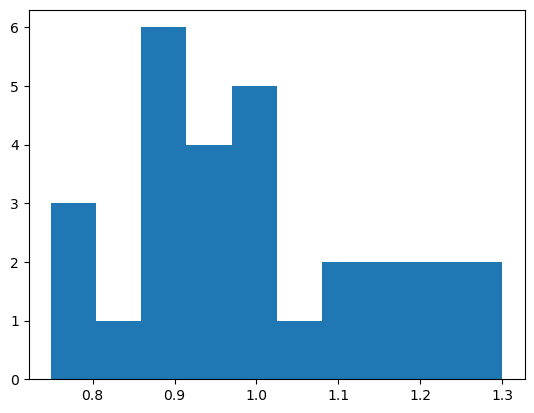

In [20]:
plt.hist(rvine_kld_dict_lambda_pen["rvine_10_dim_125obs"]["rel_kld_test"])

(array([10., 25., 26., 18., 12.,  5.,  1.,  1.,  0.,  1.]),
 array([0.5422, 0.6648, 0.7874, 0.91  , 1.0326, 1.1552, 1.2778, 1.4004,
        1.523 , 1.6456, 1.7682]),
 <BarContainer object of 10 artists>)

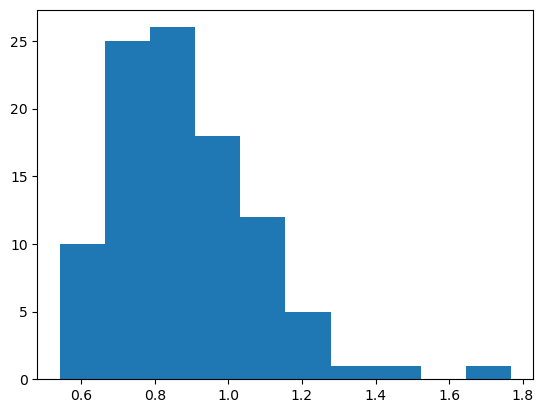

In [21]:
plt.hist(rvine_kld_dict_lambda_pen_weighted["rvine_10_dim_125obs"]["rel_kld_test"])

(array([ 5., 13., 26., 32., 11.,  7.,  4.,  1.,  1.,  1.]),
 array([0.6136 , 0.73031, 0.84702, 0.96373, 1.08044, 1.19715, 1.31386,
        1.43057, 1.54728, 1.66399, 1.7807 ]),
 <BarContainer object of 10 artists>)

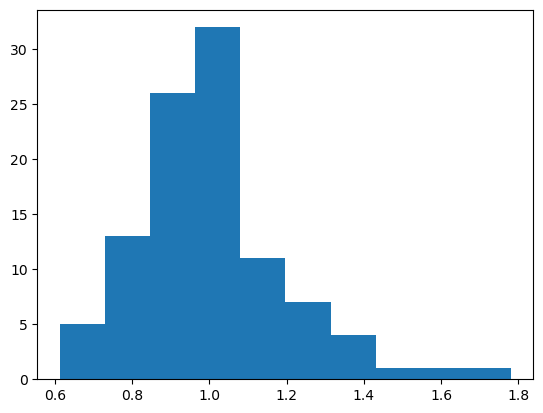

In [22]:
plt.hist(rvine_kld_dict_no_lambda_pen["rvine_10_dim_125obs"]["rel_kld_test"])

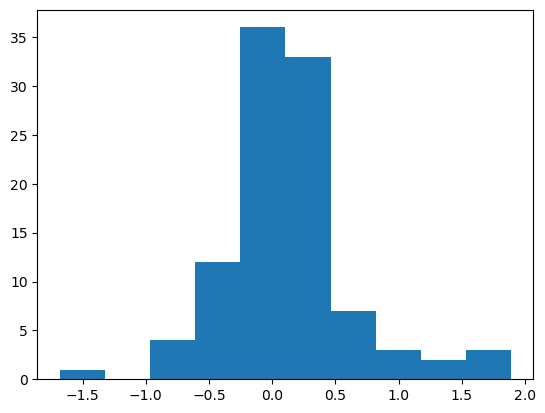

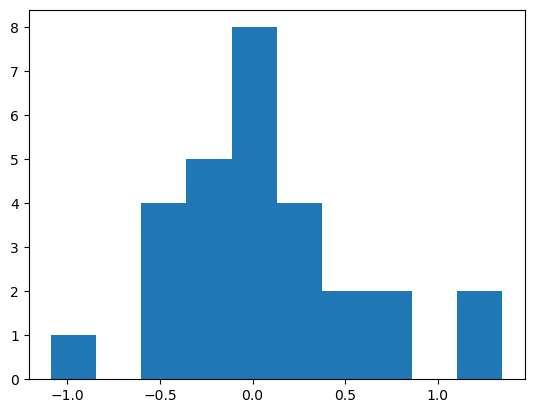

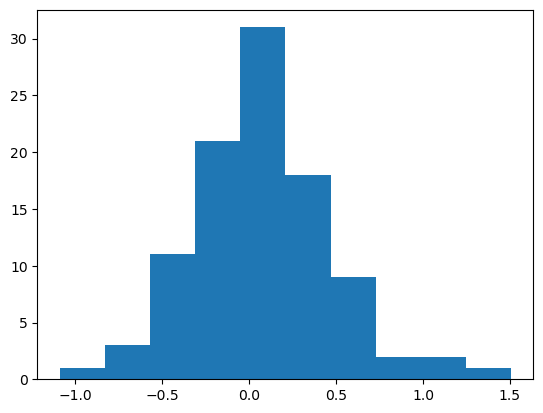

In [23]:
plt.hist(rvine_kld_dict_no_lambda_pen["rvine_10_dim_125obs"]["rel_kld_train"])
plt.show()
plt.hist(rvine_kld_dict_lambda_pen["rvine_10_dim_125obs"]["rel_kld_train"])
plt.show()
plt.hist(rvine_kld_dict_lambda_pen_weighted["rvine_10_dim_125obs"]["rel_kld_train"])
plt.show()

 for lassopen 125 obs we only have 28 seeds as then we had an error
 for weighted lassopen 250 obs we only have 22 seeds as then we had an error

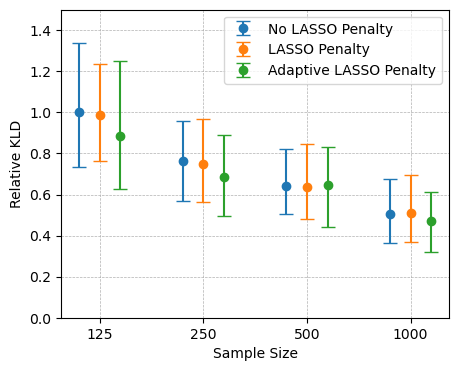

In [24]:
create_comparison_plot_one_scenario(
    rvine_kld_dict_no_lambda_pen,
    rvine_kld_dict_lambda_pen,
    rvine_kld_dict_lambda_pen_weighted,
    metric = "rel_kld_test",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000],
    experiment_strings = ["rvine_10_dim_125obs", "rvine_10_dim_250obs", "rvine_10_dim_500obs", "rvine_10_dim_1000obs"],
    y_min = 0.,
    y_max = 1.5,
    legend=True,
    metric_str="Relative KLD"
)
# save plot
#plt.savefig("gctm_jcgs_plots/rvine_kld_v2.png")

In [25]:
# lets drop the outliers, lets say everytime we have a kld in the training that is worse for a lambda approach then the worst without a lambda its a failing outlier
max_value_train = np.nanmax(rvine_kld_dict_no_lambda_pen["rvine_10_dim_125obs"]["rel_kld_train"])

rvine_kld_dict_lambda_pen_nooutliers = rvine_kld_dict_lambda_pen
for k in rvine_kld_dict_lambda_pen_nooutliers.keys():
    keep_bool = rvine_kld_dict_lambda_pen_nooutliers[k]["rel_kld_train"] < max_value_train
    rvine_kld_dict_lambda_pen_nooutliers[k]["rel_kld_test"] = list(np.array(rvine_kld_dict_lambda_pen_nooutliers[k]["rel_kld_test"])[keep_bool])
    
rvine_kld_dict_lambda_pen_weighted_nooutliers = rvine_kld_dict_lambda_pen_weighted
for k in rvine_kld_dict_lambda_pen_weighted_nooutliers.keys():
    keep_bool = rvine_kld_dict_lambda_pen_weighted_nooutliers[k]["rel_kld_train"] < max_value_train
    rvine_kld_dict_lambda_pen_weighted_nooutliers[k]["rel_kld_test"] = list(np.array(rvine_kld_dict_lambda_pen_weighted_nooutliers[k]["rel_kld_test"])[keep_bool])

IndexError: boolean index did not match indexed array along dimension 0; dimension is 28 but corresponding boolean dimension is 29

In [26]:
create_comparison_plot_one_scenario(
    rvine_kld_dict_no_lambda_pen,
    rvine_kld_dict_lambda_pen_nooutliers,
    rvine_kld_dict_lambda_pen_weighted_nooutliers,
    metric = "rel_kld_test",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000],
    experiment_strings = ["rvine_10_dim_125obs", "rvine_10_dim_250obs", "rvine_10_dim_500obs", "rvine_10_dim_1000obs"],
    y_min = 0.,
    y_max = 4,
    legend=True,
    metric_str="Relative KLD"
)
# save plot
#plt.savefig("gctm_jcgs_plots/rvine_kld_v2.png")

NameError: name 'rvine_kld_dict_lambda_pen_weighted_nooutliers' is not defined

In [27]:
def compute_stats_median(data_dict, experiment_strings, metric = "rel_kld_test"):
    median = []
    for size in experiment_strings:
        if metric is not False:
            values = data_dict[size][metric]
        else:
            values = data_dict[size]
        # drop extereme values above 5
        #values = [x for x in values if x < 3]
        median.append(np.median(values))
    return median

print(compute_stats_median(rvine_kld_dict_no_lambda_pen, experiment_strings, metric = "rel_kld_test"))
print(compute_stats_median(rvine_kld_dict_lambda_pen, experiment_strings, metric = "rel_kld_test"))
print(compute_stats_median(rvine_kld_dict_lambda_pen_weighted, experiment_strings, metric = "rel_kld_test"))



[0.9794, 0.74455, 0.6314, 0.4999]
[0.9634, 0.74245, 0.6218, 0.5057]
[0.8747, 0.67245, 0.6748000000000001, 0.47285]


NaN counts for no lambda pen: {'rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_2000obs_bootstrap_hydra_varying_copula_minimal5': 0, 'rine_10D_4000obs_bootstrap_hydra_varying_copula_minimal5': 0}


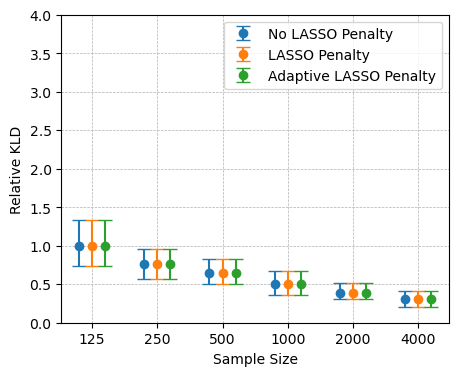

In [28]:
experiment_name_list = [
                        "rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5", 
                        "rine_10D_2000obs_bootstrap_hydra_varying_copula_minimal5",
                        "rine_10D_4000obs_bootstrap_hydra_varying_copula_minimal5"  
                        ]
rvine_kld_dict_no_lambda_pen = {}
for experiment_name in experiment_name_list:

    dict = get_rel_kld_experiment(experiment_name=experiment_name, 
                                        name_ending_look_for=False, 
                                        name_endings_not_look_for_list=["bootstrap"],
                                        seed_min=0, 
                                        seed_max=99,
                                        kld_available=False,
                                        print_info=False,
                                        print_run_names=False,
                                        copula=False)
    
    rvine_kld_dict_no_lambda_pen[experiment_name] = dict

rvine_kld_dict_no_lambda_pen, nan_counts = remove_nans_dict(rvine_kld_dict_no_lambda_pen)
print("NaN counts for no lambda pen:", nan_counts)

experiment_strings = ["rvine_10_dim_125obs", "rvine_10_dim_250obs", "rvine_10_dim_500obs", "rvine_10_dim_1000obs", "rvine_10_dim_2000obs", "rvine_10_dim_4000obs"]

del dict

# rename experiment strings in dicts
rvine_kld_dict_no_lambda_pen = dict(zip(experiment_strings, rvine_kld_dict_no_lambda_pen.values()))

create_comparison_plot_one_scenario(
    rvine_kld_dict_no_lambda_pen,
    rvine_kld_dict_no_lambda_pen,
    rvine_kld_dict_no_lambda_pen,
    metric = "rel_kld_test",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000, 2000, 4000],
    experiment_strings = experiment_strings,
    y_min = 0.,
    y_max = 4,
    legend=True,
    metric_str="Relative KLD"
)
# save plot
#plt.savefig("gctm_jcgs_plots/rvine_kld_v2.png")

In [29]:
experiment_name_list = [
                        "rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5", 
                        "rine_10D_2000obs_bootstrap_hydra_varying_copula_minimal5",
                        "rine_10D_4000obs_bootstrap_hydra_varying_copula_minimal5"]


rvine_auc_dict_no_lambda_pen = {}
for experiment_name in experiment_name_list:
    dict = get_auc_across_metrics_experiment(experiment_name=experiment_name, 
                                                name_ending_look_for=False, 
                                                name_endings_not_look_for_list=["bootstrap"],
                                                seed_min=0, 
                                                seed_max=99,
                                                print_run_names=False,)
            
    rvine_auc_dict_no_lambda_pen[experiment_name] = dict

In [30]:
import numpy as np

def remove_nans_dict_auc(rvine_auc_dict):
    nan_counts = {}
    for key, val_list in rvine_auc_dict.items():
        for k in val_list.keys():
            # Convert to numpy array for convenience
            arr = np.array(val_list[k], dtype=float)
            nan_mask = np.isnan(arr)
            num_nans = np.sum(nan_mask)
            nan_counts[key] = num_nans
            # Remove nans and update the dict
            rvine_auc_dict[key][k] = arr[~nan_mask].tolist()
    return rvine_auc_dict, nan_counts

rvine_auc_dict_no_lambda_pen, nan_counts = remove_nans_dict_auc(rvine_auc_dict_no_lambda_pen)
print("NaN counts for no lambda pen AUC:", nan_counts)

NaN counts for no lambda pen AUC: {'rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_2000obs_bootstrap_hydra_varying_copula_minimal5': 0, 'rine_10D_4000obs_bootstrap_hydra_varying_copula_minimal5': 0}


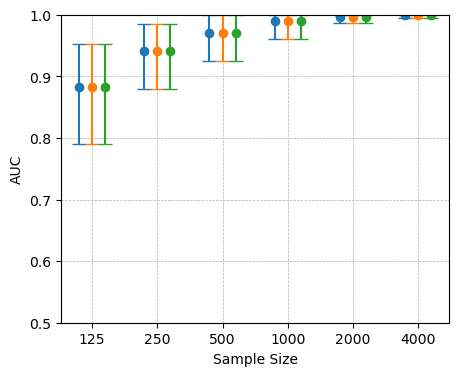

In [31]:
create_comparison_plot_one_scenario(
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_no_lambda_pen,
    metric = "metrics.auc_loglik_diff_data",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000, 2000, 4000],
    experiment_strings=experiment_name_list,
    y_min = 0.5,
    y_max = 1,
    benchmark=False
)
# save plot
#plt.savefig("gctm_jcgs_plots/cvine_auc_pmatrix.png")

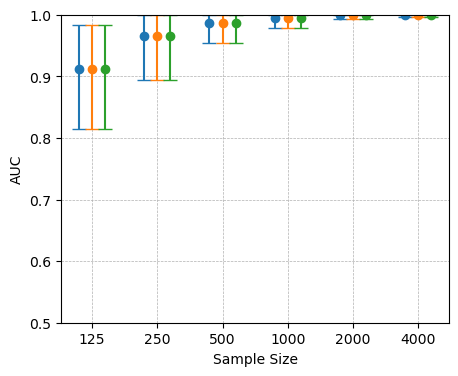

In [32]:
create_comparison_plot_one_scenario(
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_no_lambda_pen,
    metric = "metrics.auc_iae",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000, 2000,4000],
    experiment_strings=experiment_name_list,
    y_min = 0.5,
    y_max = 1,
    benchmark=False
)
# save plot
#plt.savefig("gctm_jcgs_plots/cvine_auc_pmatrix.png")

In [33]:
experiment_name_list = [
                        "rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5",  
                        "rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5"]


rvine_auc_dict_no_lambda_pen = {}
for experiment_name in experiment_name_list:
    dict = get_auc_across_metrics_experiment(experiment_name=experiment_name, 
                                                name_ending_look_for=False, 
                                                name_endings_not_look_for_list=["bootstrap"],
                                                seed_min=0, 
                                                seed_max=99,
                                                print_run_names=False,)
            
    rvine_auc_dict_no_lambda_pen[experiment_name] = dict

In [34]:
experiment_name_list = [
                        "rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5_lassopen",  
                        "rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5_lassopen",  
                        "rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5_lassopen",  
                        "rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5_lassopen"]


rvine_auc_dict_lambda_pen = {}
for experiment_name in experiment_name_list:
    dict = get_auc_across_metrics_experiment(experiment_name=experiment_name, 
                                                name_ending_look_for="meanedlassopen", 
                                                name_endings_not_look_for_list=["bootstrap"],
                                                seed_min=0, 
                                                seed_max=99,
                                                print_run_names=False,)
            
    rvine_auc_dict_lambda_pen[experiment_name] = dict

In [35]:
experiment_name_list = [
                        "rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted",  
                        "rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted",  
                        "rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted",  
                        "rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted"]


rvine_auc_dict_lambda_pen_weighted = {}
for experiment_name in experiment_name_list:
    dict = get_auc_across_metrics_experiment(experiment_name=experiment_name, 
                                                name_ending_look_for="meanedlassopen", 
                                                name_endings_not_look_for_list=["bootstrap"],
                                                seed_min=0, 
                                                seed_max=99,
                                                print_run_names=False,)
            
    rvine_auc_dict_lambda_pen_weighted[experiment_name] = dict

In [36]:
rvine_auc_dict_no_lambda_pen, nan_counts = remove_nans_dict_auc(rvine_auc_dict_no_lambda_pen)
print("NaN counts for no lambda pen AUC:", nan_counts)
rvine_auc_dict_lambda_pen, nan_counts = remove_nans_dict_auc(rvine_auc_dict_lambda_pen)
print("NaN counts for lambda pen AUC:", nan_counts)
rvine_auc_dict_lambda_pen_weighted, nan_counts = remove_nans_dict_auc(rvine_auc_dict_lambda_pen_weighted)
print("NaN counts for lambda pen weighted AUC:", nan_counts)

NaN counts for no lambda pen AUC: {'rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5': 1, 'rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5': 1}
NaN counts for lambda pen AUC: {'rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5_lassopen': 1, 'rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5_lassopen': 0, 'rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5_lassopen': 0, 'rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5_lassopen': 0}
NaN counts for lambda pen weighted AUC: {'rine_10D_125obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted': 0, 'rine_10D_250obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted': 0, 'rine_10D_500obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted': 1, 'rine_10D_1000obs_bootstrap_hydra_varying_copula_minimal5_lassopen_weighted': 0}


In [37]:
experiment_strings = ["rvine_10_dim_125obs", "rvine_10_dim_250obs", "rvine_10_dim_500obs", "rvine_10_dim_1000obs"]

del dict

# rename experiment strings in dicts
rvine_auc_dict_no_lambda_pen = dict(zip(experiment_strings, rvine_auc_dict_no_lambda_pen.values()))
rvine_auc_dict_lambda_pen = dict(zip(experiment_strings, rvine_auc_dict_lambda_pen.values()))
rvine_auc_dict_lambda_pen_weighted = dict(zip(experiment_strings, rvine_auc_dict_lambda_pen_weighted.values()))

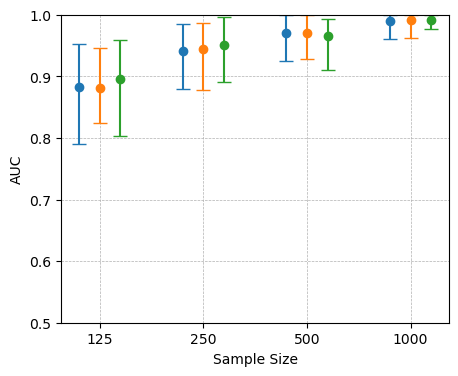

In [38]:
create_comparison_plot_one_scenario(
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_lambda_pen,
    rvine_auc_dict_lambda_pen_weighted,
    metric = "metrics.auc_loglik_diff_data",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000],
    experiment_strings=experiment_strings,
    y_min = 0.5,
    y_max = 1,
    benchmark=False
)
# save plot
#plt.savefig("gctm_jcgs_plots/cvine_auc_pmatrix.png")

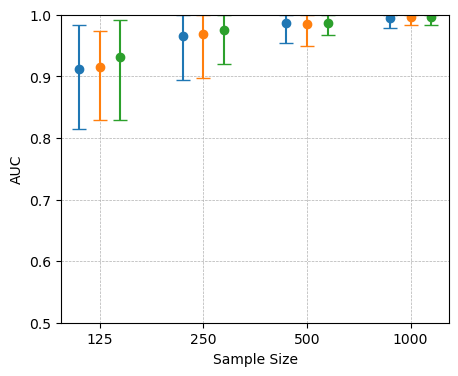

In [39]:
create_comparison_plot_one_scenario(
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_lambda_pen,
    rvine_auc_dict_lambda_pen_weighted,
    metric = "metrics.auc_iae",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000],
    experiment_strings=experiment_strings,
    y_min = 0.5,
    y_max = 1,
    benchmark=False
)
# save plot
#plt.savefig("gctm_jcgs_plots/cvine_auc_pmatrix.png")

In [98]:
rvine_auc_dict_no_lambda_pen["rvine_10_dim_1000obs"].keys()

dict_keys(['metrics.auc_cond_corr_val', 'metrics.auc_loglik_diff_train', 'metrics.auc_cond_corr', 'metrics.auc_precision_matrix', 'metrics.auc_kld', 'metrics.auc_precision_matrix_train', 'metrics.auc_precision_matrix_val', 'metrics.auc_loglik_diff_val', 'metrics.auc_iae', 'metrics.auc_precision_matrix_data', 'metrics.auc_loglik_diff_data', 'metrics.auc_cond_corr_data', 'metrics.auc_cond_corr_train'])

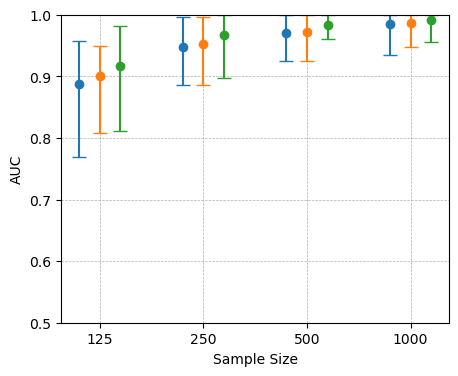

In [40]:
create_comparison_plot_one_scenario(
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_lambda_pen,
    rvine_auc_dict_lambda_pen_weighted,
    metric = "metrics.auc_cond_corr",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000],
    experiment_strings=experiment_strings,
    y_min = 0.5,
    y_max = 1,
    benchmark=False
)
# save plot
#plt.savefig("gctm_jcgs_plots/cvine_auc_pmatrix.png")

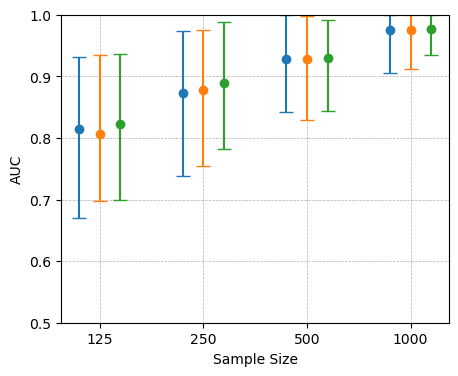

In [50]:
create_comparison_plot_one_scenario(
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_lambda_pen,
    rvine_auc_dict_lambda_pen_weighted,
    metric = "metrics.auc_loglik_diff_val",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000],
    experiment_strings=experiment_strings,
    y_min = 0.5,
    y_max = 1,
    benchmark=False
)
# save plot
#plt.savefig("gctm_jcgs_plots/cvine_auc_pmatrix.png")

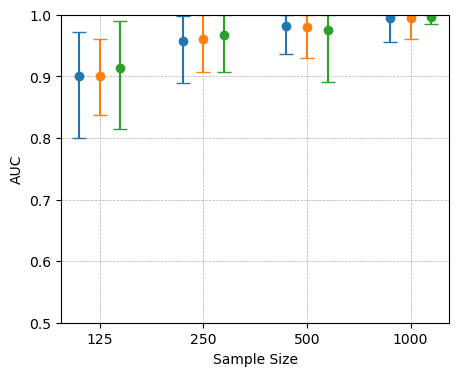

In [51]:
create_comparison_plot_one_scenario(
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_lambda_pen,
    rvine_auc_dict_lambda_pen_weighted,
    metric = "metrics.auc_loglik_diff_train",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000],
    experiment_strings=experiment_strings,
    y_min = 0.5,
    y_max = 1,
    benchmark=False
)
# save plot
#plt.savefig("gctm_jcgs_plots/cvine_auc_pmatrix.png")

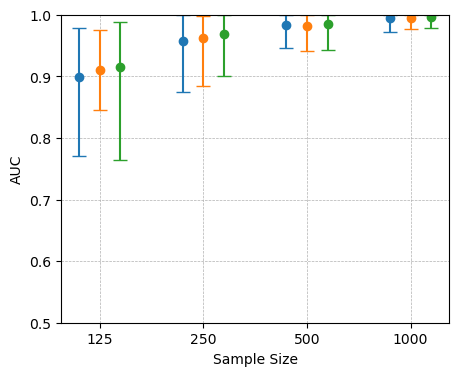

In [53]:
create_comparison_plot_one_scenario(
    rvine_auc_dict_no_lambda_pen,
    rvine_auc_dict_lambda_pen,
    rvine_auc_dict_lambda_pen_weighted,
    metric = "metrics.auc_kld",
    title_str = "R-Vine",
    sample_sizes = [125, 250, 500, 1000],
    experiment_strings=experiment_strings,
    y_min = 0.5,
    y_max = 1,
    benchmark=False
)
# save plot
#plt.savefig("gctm_jcgs_plots/cvine_auc_pmatrix.png")

In [49]:
rvine_auc_dict_no_lambda_pen['rvine_10_dim_125obs'].keys()

dict_keys(['metrics.auc_cond_corr_val', 'metrics.auc_cond_corr', 'metrics.auc_loglik_diff_val', 'metrics.auc_cond_corr_data', 'metrics.auc_loglik_diff_train', 'metrics.auc_cond_corr_train', 'metrics.auc_precision_matrix', 'metrics.auc_loglik_diff_data', 'metrics.auc_iae', 'metrics.auc_precision_matrix_train', 'metrics.auc_precision_matrix_val', 'metrics.auc_precision_matrix_data', 'metrics.auc_kld'])